In [111]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [117]:
# 1. Load your background image
image = plt.imread('Siibra_explorer_v2.png')
# For demonstration, we'll create a dummy image array
#image = np.random.rand(100, 100, 3) 

# 2. Setup your data
data = pd.read_csv("location_frequency_data.csv")


regions = data["brain region"].unique()
location_dict = {"occipital cortex": [740, 180], "striatum": [740, 470],
                 "somatosensory": [825, 270], "PFC": [470, 330],
                 "neocortex": [520, 220], "hippocampus (CA1-3)": [780, 330],
                 "cerebellar cortex": [930, 250], "olfactory bulb": [340, 480],
                 "hippocampus (subiculum)": [660, 240]}

"""
for region in regions:
    sub_df = data[data["brain region"] == region]
    for _, row in sub_df.iterrows():
        x_loc = np.array(location_dict[region][0]) + 10*np.random.choice(np.array([-2, -1, 0, 1, 2]))
        y_loc = np.array(location_dict[region][1]) + 10*np.random.choice(np.array([-2, -1, 0, 1, 2]))
        row['x_loc'] = x_loc
        row['y_loc'] = y_loc
"""
print(data.head())
for _, row in data.iterrows():
    region = row['brain region']
    x_loc = np.array(location_dict[region][0]) + 10*np.random.choice(np.array([-2, -1, 0, 1, 2]))
    y_loc = np.array(location_dict[region][1]) + 10*np.random.choice(np.array([-2, -1, 0, 1, 2]))
    row['x_loc'] = x_loc
    row['y_loc'] = y_loc

print(data.head())



       brain region type  proportion (%) Species  x_loc  y_loc
0  occipital cortex    E            50.0     Rat    740    190
1          striatum    I            66.7     Rat    740    470
2          striatum    I            94.0     Rat    705    475
3     somatosensory    E            80.0     rat    825    270
4               PFC    E            56.4   mouse    470    330
       brain region type  proportion (%) Species  x_loc  y_loc
0  occipital cortex    E            50.0     Rat    740    190
1          striatum    I            66.7     Rat    740    470
2          striatum    I            94.0     Rat    705    475
3     somatosensory    E            80.0     rat    825    270
4               PFC    E            56.4   mouse    470    330


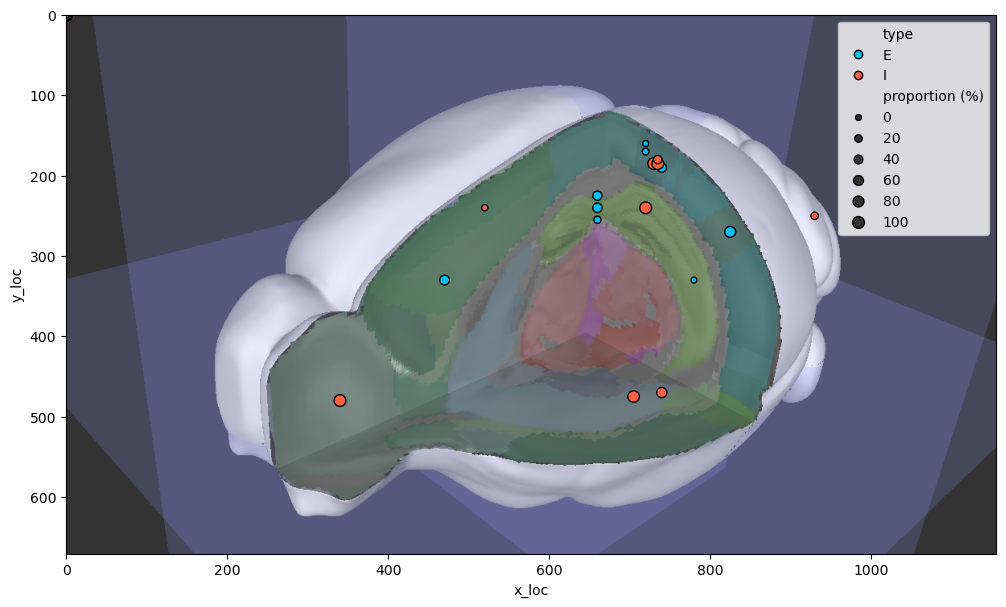

In [113]:
# 3. Create the plot
fig, ax = plt.subplots(figsize=(12, 7))

# Plot the Seaborn data
palette = {'E': 'deepskyblue', 'I': 'tomato'}
sns.scatterplot(data=data, x="x_loc", y="y_loc", hue = "type", size = "proportion (%)", palette = palette, 
                ax=ax, zorder=2, linewidths = 1, edgecolor = 'black')

# 4. Add the background image
# 'extent' maps the image to the [xmin, xmax, ymin, ymax] of your data
ax.imshow(image, aspect='auto', 
          alpha=0.8, # Adjust transparency so data is readable
          zorder=1)  # Keeps the image behind the scatter points

plt.show()